In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:34837")
client

<Client: 'tcp://127.0.0.1:34837' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

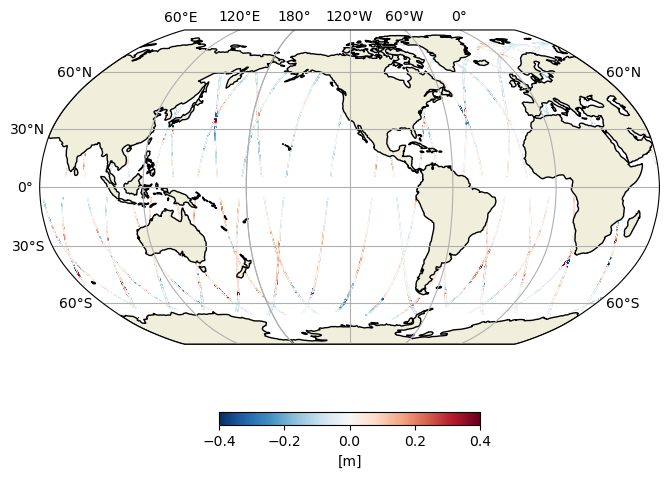

In [28]:
import cartopy.crs as ccrs
import cartopy.util as cutil
import cartopy.feature as cfeature

cnum = 20
nsep = 4300

fig = plt.figure(figsize=(9,5))
fig.set_tight_layout(True)
# plot with central longitude 0
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.Robinson(central_longitude=240)
                    )
ax.set_global()
for ipass in range(1,26):
    low = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % ipass)
                      ).ssha
    lati = low.latitude
    longi = low.longitude
    if (longi.max(skipna=True)-longi.min(skipna=True)) > 180.:
        long_adjusted = xr.where(longi > 180, longi - 360, longi)
    else:
        # long_masked = long.copy()
        long_adjusted = longi
        
    if ipass == 12:
        im = ax.pcolormesh(long_adjusted.isel(num_lines=slice(None,nsep)), 
                      lati.isel(num_lines=slice(None,nsep)), 
                      low.isel(cycle_num=cnum,num_lines=slice(None,nsep)),
                      transform=ccrs.PlateCarree(), 
                      cmap='RdBu_r',
                      vmin=-.4, vmax=.4,
                      rasterized=True)
        ax.pcolormesh(long_adjusted.isel(num_lines=slice(nsep+400,None)), 
                      lati.isel(num_lines=slice(nsep+400,None)), 
                      low.isel(cycle_num=cnum,num_lines=slice(nsep+400,None)),
                      transform=ccrs.PlateCarree(), 
                      cmap='RdBu_r',
                      vmin=-.4, vmax=.4,
                      rasterized=True)
    elif ipass == 25:
        ax.pcolormesh(long_adjusted.isel(num_lines=slice(2050,None)), 
                      lati.isel(num_lines=slice(2050,None)), 
                      low.isel(cycle_num=cnum,num_lines=slice(2050,None)),
                      transform=ccrs.PlateCarree(), 
                      cmap='RdBu_r',
                      vmin=-.4, vmax=.4,
                      rasterized=True)
        ax.pcolormesh(long_adjusted.isel(num_lines=slice(None,1700)), 
                      lati.isel(num_lines=slice(None,1700)), 
                      low.isel(cycle_num=cnum,num_lines=slice(None,1700)),
                      transform=ccrs.PlateCarree(), 
                      cmap='RdBu_r',
                      vmin=-.4, vmax=.4,
                      rasterized=True)
    else:
        ax.pcolormesh(long_adjusted, lati, low.isel(cycle_num=cnum),
                      transform=ccrs.PlateCarree(), 
                      cmap='RdBu_r',
                      vmin=-.4, vmax=.4,
                      rasterized=True)
    del low, long_adjusted
# ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')
gl = ax.gridlines(draw_labels=True)
gl.bottom_labels = False
gl.right_labels = False
cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.3)
cbar.set_label(r"[m]")
plt.savefig(op.join(ddir,"../Figs/ssha-CalVal.pdf"))